In [156]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix

In [157]:
df= pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [158]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [159]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


> oops! there are object columns more than you think. Donnorry, we are going to do it as numeric.

In [161]:
df.drop(columns= 'customerID', axis=1, inplace= True)

> CustomerId isnt important so we droped that.It isnt going to do any help.So its not important here as our life.

In [162]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [163]:
for i in df.columns:
    if df[i].dtypes == 'object':
        print(f'{i} : {df[i].value_counts()}')
        print('='*50)


gender : gender
Male      3555
Female    3488
Name: count, dtype: int64
Partner : Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents : Dependents
No     4933
Yes    2110
Name: count, dtype: int64
PhoneService : PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines : MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService : InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity : OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup : OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection : DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
TechSupport : TechSupport
No   


> haah! There are types of values like "No internet service, No phone Service" many more.What do we do now?thinking.....i gotta idea. think bout it like if we convert no internet service or no phone charges as no. how would this be? I think not bad atll. Lets do it! yey


# Now we replacing the wired values like 'No internet services' as No and Converting it into binary

In [164]:
for i in df:
    if df[i].dtypes == 'object':
        if 'No internet service' or 'No phone service' in df[i]:
            df[i]= df[i].replace({
                'No internet service' : 'No',
                'No phone service' : 'No'
            })

In [165]:
for col in df.columns:
    if df[col].dtype == 'object':
        if set(df[col].unique())== {'Yes', 'No'}:
            df[col] = df[col].map({'Yes': 1, 'No': 0})
df['gender']= df['gender'].map({'Male': 0, 'Female': 1})

**If you see the TotalCharges column, you can see there are each value looks numeric. But all are showing object values. So we are going convert it as numeric. First we will check values, if the column has space or any other wired string. then we will decide what we can do**

In [166]:
df['TotalCharges']= pd.to_numeric(df['TotalCharges'], errors='coerce')
df= df.dropna(subset= ['TotalCharges'])

> I removed the 11 rows. There was 7043 rows and i removed string types values rows. i dont think its not a big deal.

**Some column has more than 2 values so we are going to do one hot encoding**

In [167]:
df= pd.get_dummies(columns= ['InternetService', 'Contract', 'PaymentMethod'], drop_first= True, data=df)

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   MultipleLines                          7032 non-null   int64  
 7   OnlineSecurity                         7032 non-null   int64  
 8   OnlineBackup                           7032 non-null   int64  
 9   DeviceProtection                       7032 non-null   int64  
 10  TechSupport                            7032 non-null   int64  
 11  Streaming

In [169]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.495307,0.162400,0.482509,0.298493,32.421786,0.903299,0.421928,0.286547,0.344852,0.343857,0.290102,0.384386,0.388367,0.592719,64.798208,2283.300441,0.265785
std,0.500014,0.368844,0.499729,0.457629,24.545260,0.295571,0.493902,0.452180,0.475354,0.475028,0.453842,0.486484,0.487414,0.491363,30.085974,2266.771362,0.441782
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.587500,401.450000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1397.475000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.862500,3794.737500,1.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,1.000000


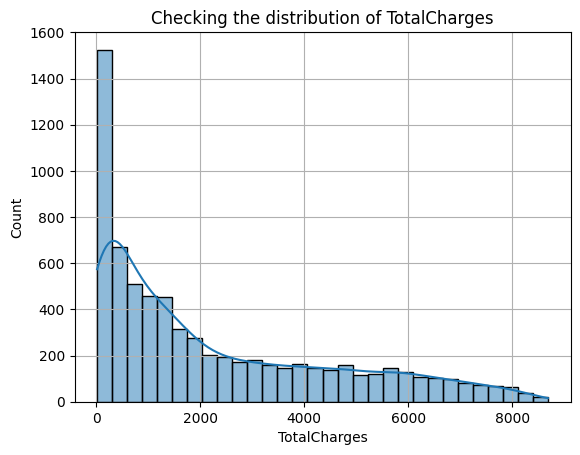

In [170]:
sns.histplot(df['TotalCharges'],bins=30, kde= True)
plt.title('Checking the distribution of TotalCharges')
plt.grid(True)
plt.show()

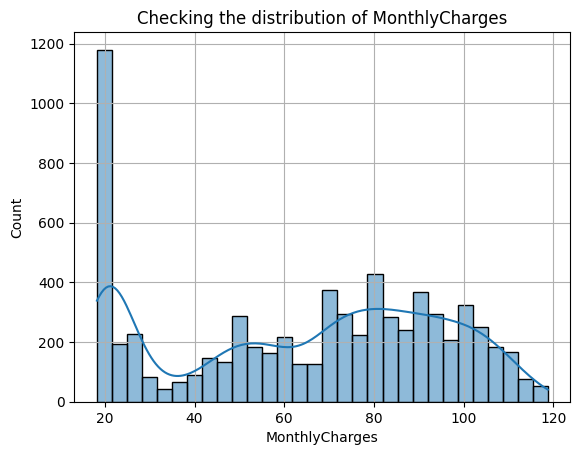

In [171]:
sns.histplot(df['MonthlyCharges'],bins=30, kde= True)
plt.title('Checking the distribution of MonthlyCharges')
plt.grid(True)
plt.show()

> I dont think there are any major problem in MonthlyCharges and TotalCharges

In [172]:
X= df.drop('Churn', axis=1)
y= df['Churn']

# Scaling the data

In [173]:
scaler= StandardScaler()
X_scaled= scaler.fit_transform(X)

# train data

In [174]:
X_train, X_test, y_train, y_test= train_test_split(X_scaled,y, test_size= 0.2, random_state=42)

In [175]:
X_train.shape

(5625, 23)

# Now Lets dive into the ANN

In [176]:
import tensorflow as tf
from tensorflow import keras

In [177]:
model= keras.Sequential([
    keras.layers.Dense(20, input_shape=(23,), activation= 'relu'),
    # keras.layers.Dense(15, activation= 'relu'),
    # keras.layers.Dense(10, activation= 'relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer= 'adam',
    loss= 'binary_crossentropy',
    metrics= ['accuracy']
)

model.fit(X_train, y_train, epochs=100)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6786 - loss: 0.5809
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7870 - loss: 0.4537
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7956 - loss: 0.4315
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7984 - loss: 0.4221
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8012 - loss: 0.4167
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8039 - loss: 0.4130
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8034 - loss: 0.4104
Epoch 8/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8041 - loss: 0.4082
Epoch 9/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8050 - loss: 0.4066
Epoch 10/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8053 - loss: 0.4054
Epoch 11/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8052 - loss: 0.4038
Epoch 12/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

> we used diferrent hidden layers and its little bit changing, but not much. And we used binary_crossentropy. bcz we know churn and whole dataset is in binary types. so, if we see the accuracy and loss, it isnt bad. so, lets do next!> 

In [178]:
model.evaluate(X_test, y_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7868 - loss: 0.4579


[0.45789867639541626, 0.7867803573608398]

> we got almost 80% accuracy. good to see!

# Lets Predict

In [179]:
y_pred= model.predict(X_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [180]:
y_pred[:5]

array([[0.01583632],
       [0.18125547],
       [0.673776  ],
       [0.0171548 ],
       [0.36696905]], dtype=float32)

> oh man! y_pred got 2D array as you are doing double timing

**Now we are converting the fractional y_pred to int or binary and the 2D array will gone also.For example if the array has more than 0.5 values,itll convert as 1 else 0**

In [181]:
y_pred_bi=[]
for i in y_pred:
    if i > 0.50:
        y_pred_bi.append(1)
    else:
        y_pred_bi.append(0)

In [182]:
y_pred_bi[:5]

[0, 0, 1, 0, 0]

In [183]:
y_test[:5]

2481    0
6784    0
6125    1
3052    0
4099    0
Name: Churn, dtype: int64

> both are ok now!

In [184]:
print(classification_report(y_test, y_pred_bi))

              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1033
           1       0.61      0.55      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407



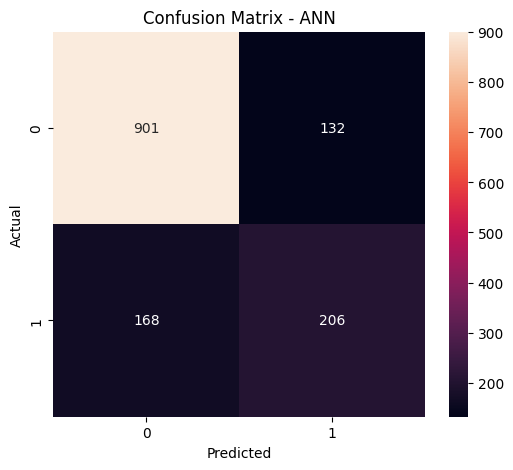

In [185]:
cm= tf.math.confusion_matrix(y_test, y_pred_bi)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d'), 
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - ANN')
plt.show()

> Looks so good ig! Our model predicted 912 plus 191 times predicted correct and 183 plus 121 times predicted errors.

In [186]:
Acc= round((912+191) / (912+191+121+183),2)
print(Acc)

0.78


> Our model's Accuracy is 78%

**So, Thats for today!**